# 02 · Exploratory analysis - what drives returns (dispatch-time information only)

Input: the cleaned pack from `kestrel.data` (policy.md §2 rules C1–C4). Banned columns (policy.md §4) are never examined as drivers here.

| § | Question |
|---|---|
| 0 | Does the pincode region match the customer's city? |
| 1 | Region / city: real effect or proxy (channel, family, partner outlets)? |
| 2 | Univariate drivers (with 95% intervals) and a signal-strength ranking |
| 3 | Key interactions (Shield × prior returns, family × channel, COD × discount, gift × family) |
| 4 | Tenure: any signal once the impossible values are guarded? |
| 5 | Stability over time and season |
| 6 | Train vs test shift |
| 7 | Order value by family → margin input for Phase 5 |
| 8 | Stakeholder claims |
| 9 | Summary → decisions |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

from kestrel.config import FIGURES_DIR, CALL_COST_INR, HOLD_CANCEL_RATE
from kestrel.data import load_pack, attach_reference

pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

pack = load_pack()
tr = attach_reference(pack["train"], pack["customers"], pack["products"])
te = attach_reference(pack["test"], pack["customers"], pack["products"])
BASE = tr.returned.mean()
print(tr.shape, te.shape, f"base return rate {BASE:.4f}")

(10504, 30) (2096, 29) base return rate 0.1142


In [2]:
# --- Chart style (dataviz reference palette, light mode). One hue for single-series bars,
# grey reference line for the base rate, recessive solid grid, legend whenever >= 2 series.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e6e5e0", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.titlecolor": INK, "font.size": 10, "legend.frameon": False,
})

def wilson(k, n, z=1.96):
    """95% Wilson interval for a proportion."""
    p = k / n
    centre = (p + z * z / (2 * n)) / (1 + z * z / n)
    half = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / (1 + z * z / n)
    return centre - half, centre + half

def rate_table(df, col, order=None):
    g = df.groupby(col, observed=True).returned.agg(orders="size", returns="sum")
    g["rate"] = g.returns / g.orders
    lo, hi = wilson(g.returns, g.orders)
    g["ci_low"], g["ci_high"] = lo, hi
    g["lift"] = g.rate / BASE
    if order is not None:
        g = g.reindex(order)
    return g.round(3)

def rate_bars(t, title, fname=None, ax=None, color=BLUE, horizontal=False):
    """Return-rate bars with 95% CI whiskers and the base-rate reference line."""
    own = ax is None
    if own:
        fig, ax = plt.subplots(figsize=(7, 0.32 * len(t) + 1.4) if horizontal else (7, 3.6))
    labels = [str(i) for i in t.index]
    err = np.vstack([t.rate - t.ci_low, t.ci_high - t.rate]) * 100
    if horizontal:
        ax.barh(labels, t.rate * 100, color=color, height=0.6, xerr=err, ecolor=INK2, capsize=2, error_kw={"lw": 1})
        ax.axvline(BASE * 100, color=INK2, lw=1)
        ax.set_xlabel("return rate, % (95% interval)"); ax.invert_yaxis(); ax.grid(axis="y", visible=False)
    else:
        ax.bar(labels, t.rate * 100, color=color, width=0.6, yerr=err, ecolor=INK2, capsize=2, error_kw={"lw": 1})
        ax.axhline(BASE * 100, color=INK2, lw=1)
        ax.set_ylabel("return rate, % (95% interval)"); ax.grid(axis="x", visible=False)
    ax.set_title(title, loc="left")
    if own:
        ax.annotate(f"all orders {BASE:.1%}", xy=(1, BASE * 100) if not horizontal else (BASE * 100, 1),
                    xycoords=("axes fraction", "data") if not horizontal else ("data", "axes fraction"),
                    ha="right" if not horizontal else "left", va="bottom", color=INK2, fontsize=9)
        fig.tight_layout()
        if fname:
            fig.savefig(FIGURES_DIR / fname, dpi=150)
        plt.show()

## 0 · Pincode region vs customer city
For orders with a real pincode, does the region (first 3 digits) match the city on the customer record?

In [3]:
real = tr[tr.delivery_pincode != "0"].copy()
real["region"] = real.delivery_pincode.str[:3]
city_region = pd.crosstab(real.city, real.region)
city_region["orders"] = city_region.sum(axis=1)
city_region["share_in_440"] = (city_region["440"] / city_region.orders).round(3)
city_region.sort_values("share_in_440")

region,110,400,411,440,500,560,600,orders,share_in_440
city,,,,,,,,,
Bengaluru,0,0,0,0,0,574,0,574,0.0
Chennai,0,0,0,0,0,0,438,438,0.0
Hyderabad,0,0,0,0,532,0,0,532,0.0
Delhi,581,0,0,0,0,0,0,581,0.0
Mumbai,0,581,0,0,0,0,0,581,0.0
Pune,0,0,525,0,0,0,0,525,0.0
Coimbatore,0,0,0,565,0,0,0,565,1.0
Bhopal,0,0,0,496,0,0,0,496,1.0
Hubballi,0,0,0,545,0,0,0,545,1.0


In [4]:
r440 = real[real.region == "440"]
print(f"orders with region 440: {len(r440)} | from Nagpur customers: {(r440.city == 'Nagpur').sum()} ({(r440.city == 'Nagpur').mean():.1%})")
print("cities behind region 440:", r440.city.nunique(), sorted(r440.city.unique()))
metro_regions = real[real.region != "440"].groupby("region").city.agg(lambda s: f"{s.mode()[0]} ({(s == s.mode()[0]).mean():.0%})")
print("non-440 regions -> city (match rate):", metro_regions.to_dict())
te_real = te[te.delivery_pincode != "0"]
print(f"test: region-440 orders from non-Nagpur customers = {((te_real.delivery_pincode.str[:3] == '440') & (te_real.city != 'Nagpur')).mean():.1%} of real-pincode orders")

orders with region 440: 6425 | from Nagpur customers: 541 (8.4%)
cities behind region 440: 12 ['Aurangabad', 'Bhopal', 'Coimbatore', 'Hubballi', 'Indore', 'Jaipur', 'Kota', 'Lucknow', 'Mysuru', 'Nagpur', 'Nashik', 'Warangal']
non-440 regions -> city (match rate): {'110': 'Delhi (100%)', '400': 'Mumbai (100%)', '411': 'Pune (100%)', '500': 'Hyderabad (100%)', '560': 'Bengaluru (100%)', '600': 'Chennai (100%)'}
test: region-440 orders from non-Nagpur customers = 63.9% of real-pincode orders


**Reading: the pincode field is unreliable outside the six metros.**
- Every customer in the 12 non-metro cities (Aurangabad, Bhopal, Coimbatore, Hubballi, Indore, Jaipur, Kota, Lucknow, Mysuru, Nagpur, Nashik, Warangal) has a `440xxx` (Nagpur) pincode. **Only 8.4% of region-440 orders belong to Nagpur customers.**
- The six metro regions match their city 100% (110 Delhi, 400 Mumbai, 411 Pune, 500 Hyderabad, 560 Bengaluru, 600 Chennai).
- Same pattern in test (64% of real-pincode test orders are 440 from non-Nagpur customers).

**Decision: drop pincode region as a feature; use the customer's `city` / `state` instead** (passed with the order at serve time, joined from `customers.csv` in training). Keep `address_missing` (pincode `0`) as a candidate flag. The "Nagpur effect" from Phase 1 is really a **non-metro customer effect**.

## 1 · City effect: real or proxy?

In [5]:
METROS = ["Delhi", "Mumbai", "Pune", "Hyderabad", "Bengaluru", "Chennai"]
for d in (tr, te):
    d["metro"] = np.where(d.city.isin(METROS), "metro", "non-metro")
    d["address_missing"] = (d.delivery_pincode == "0").astype(int)
city_t = rate_table(tr, "city").sort_values("rate", ascending=False)
city_t["tier"] = np.where(city_t.index.isin(METROS), "metro", "non-metro")
city_t

,orders,returns,rate,ci_low,ci_high,lift,tier
city,,,,,,,
Aurangabad,518,83,0.160,0.131,0.194,1.403,non-metro
Kota,633,94,0.148,0.123,0.178,1.300,non-metro
Hubballi,597,87,0.146,0.120,0.176,1.276,non-metro
Mysuru,578,83,0.144,0.117,0.175,1.257,non-metro
Bhopal,536,77,0.144,0.116,0.176,1.257,non-metro
Nashik,594,85,0.143,0.117,0.174,1.253,non-metro
Warangal,624,84,0.135,0.110,0.164,1.178,non-metro
Nagpur,591,76,0.129,0.104,0.158,1.126,non-metro
Coimbatore,614,64,0.104,0.082,0.131,0.912,non-metro


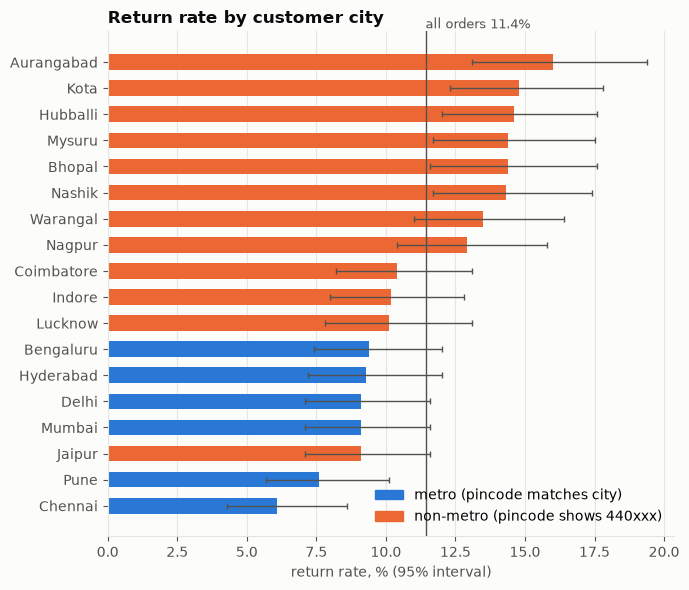

In [6]:
fig, ax = plt.subplots(figsize=(7, 6))
colors = [BLUE if t == "metro" else ORANGE for t in city_t.tier]
err = np.vstack([city_t.rate - city_t.ci_low, city_t.ci_high - city_t.rate]) * 100
ax.barh(city_t.index, city_t.rate * 100, color=colors, height=0.6, xerr=err, ecolor=INK2, capsize=2, error_kw={"lw": 1})
ax.axvline(BASE * 100, color=INK2, lw=1); ax.invert_yaxis(); ax.grid(axis="y", visible=False)
ax.set_xlabel("return rate, % (95% interval)")
ax.set_title("Return rate by customer city", loc="left")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=BLUE, label="metro (pincode matches city)"), Patch(color=ORANGE, label="non-metro (pincode shows 440xxx)")], loc="lower right")
ax.annotate(f"all orders {BASE:.1%}", xy=(BASE * 100, 1.0), xycoords=("data", "axes fraction"), ha="left", va="bottom", color=INK2, fontsize=9)
fig.tight_layout(); fig.savefig(FIGURES_DIR / "02_city_return_rate.png", dpi=150); plt.show()

In [7]:
# Proxy check: is the metro / non-metro gap explained by channel, family, partner outlets, Shield or prior returns?
def gap_within(col):
    t = tr.pivot_table(index=col, columns="metro", values="returned", aggfunc="mean", observed=True)
    n = tr.pivot_table(index=col, columns="metro", values="returned", aggfunc="size", observed=True)
    t["gap_pts"] = (t["non-metro"] - t["metro"]) * 100
    t["orders"] = n.sum(axis=1)
    return t.round(3)
for col in ["sales_channel", "family", "shield_member"]:
    print(f"--- within {col}"); display(gap_within(col))
tr["has_prior_return"] = (tr.customer_prior_returns > 0).astype(int)
print("--- within has_prior_return"); display(gap_within("has_prior_return"))
mix = pd.crosstab(tr.metro, tr.sales_channel, normalize="index").round(3)
print("channel mix by tier:"); display(mix)

--- within sales_channel


metro,metro,non-metro,gap_pts,orders
sales_channel,,,,
app,0.072,0.125,5.275,3582
marketplace,0.109,0.150,4.138,2869
partner_outlet,0.066,0.102,3.593,1287
web,0.086,0.125,3.903,2766


--- within family


metro,metro,non-metro,gap_pts,orders
family,,,,
Air Fryer,0.098,0.131,3.225,1516
Ceiling Fan,0.049,0.076,2.771,1531
Induction Cooktop,0.059,0.095,3.641,1476
Mixer Grinder,0.050,0.077,2.640,1451
Robot Vacuum,0.135,0.223,8.757,1554
Room Heater,0.076,0.137,6.048,1525
Water Purifier,0.137,0.154,1.639,1451


--- within shield_member


metro,metro,non-metro,gap_pts,orders
shield_member,,,,
N,0.071,0.105,3.436,8177
Y,0.132,0.218,8.644,2327


--- within has_prior_return


metro,metro,non-metro,gap_pts,orders
has_prior_return,,,,
0,0.065,0.104,3.864,9119
1,0.220,0.296,7.624,1385


channel mix by tier:


sales_channel,app,marketplace,partner_outlet,web
metro,,,,
metro,0.335,0.285,0.116,0.265
non-metro,0.344,0.267,0.126,0.263


**Reading: the city effect is real, not a proxy (as far as this data can show).**
- Non-metro customers return 12.9% vs 8.5% in metros. The gap **persists inside every channel** (+3.6 to +5.3 pts), **every family** (+1.6 to +8.8), both Shield groups and both prior-return groups. The channel mix is the same in both tiers (partner outlets 12.6% vs 11.6%).
- It isn't a clean metro/non-metro split: Jaipur (9.1%), Lucknow, Indore and Coimbatore (~10%) look like metros, while Aurangabad, Kota, Hubballi, Mysuru, Bhopal and Nashik sit at 14–16%. **City carries more information than a metro flag**, but each city has only ~500–630 orders, so per-city estimates are noisy (intervals ±3 pts).

**Decision:** the model gets **`city` (18 levels, regularised)** as a candidate, with `metro` as the simpler alternative. Phase 4 picks one by validation.

## 2 · Univariate drivers

In [8]:
tr["discount_band"] = pd.cut(tr.discount_pct, [-0.1, 0, 5, 10, 15, 20, 100], labels=["0", "1-5", "6-10", "11-15", "16-20", ">20"])
tr["value_band"] = pd.qcut(tr.order_value_inr, 5, labels=["Q1 low", "Q2", "Q3", "Q4", "Q5 high"])
tr["prior_returns_c"] = tr.customer_prior_returns.clip(upper=3).astype(str).replace({"3": "3+"})
tr["prior_orders_c"] = tr.customer_prior_orders.clip(upper=4).astype(str).replace({"4": "4+"})
tr["promised_band"] = pd.cut(tr.promised_delivery_days, [0, 3, 5, 7, 12], labels=["1-3", "4-5", "6-7", "8-12"])
tr["tier"] = tr.model_name.str.split().str[-1]
tr["hour_band"] = pd.cut(tr.order_ts.dt.hour, [-1, 5, 11, 17, 23], labels=["00-05", "06-11", "12-17", "18-23"])
tr["weekday"] = tr.order_ts.dt.day_name().str[:3]
import re
tpl = tr.delivery_note.fillna("").str.replace(r"\d+[A-Z]?", "#", regex=True)
known = tpl.value_counts()[lambda s: s >= 20].index
tr["note_cat"] = np.where(tr.delivery_note.isna(), "none", np.where(tpl.isin(known), tpl, "other"))
tr["note_present"] = tr.delivery_note.notna().astype(int)

DRIVERS = ["prior_returns_c", "prior_orders_c", "shield_member", "family", "tier", "sales_channel", "payment_mode",
           "discount_band", "value_band", "is_gift", "qty", "promised_band", "address_missing", "metro",
           "warranty_months", "hour_band", "weekday", "note_present"]
tables = {c: rate_table(tr, c) for c in DRIVERS}
for c in DRIVERS:
    print(f"--- {c}"); display(tables[c])

--- prior_returns_c


,orders,returns,rate,ci_low,ci_high,lift
prior_returns_c,,,,,,
0,9119,826,0.091,0.085,0.097,0.793
1,1038,207,0.199,0.176,0.225,1.746
2,223,91,0.408,0.346,0.474,3.572
3+,124,76,0.613,0.525,0.694,5.365


--- prior_orders_c


,orders,returns,rate,ci_low,ci_high,lift
prior_orders_c,,,,,,
0,2996,266,0.089,0.079,0.100,0.777
1,3579,338,0.094,0.085,0.104,0.827
2,2308,261,0.113,0.101,0.127,0.990
3,990,157,0.159,0.137,0.183,1.388
4+,631,178,0.282,0.248,0.318,2.469


--- shield_member


...

,orders,returns,rate,ci_low,ci_high,lift
hour_band,,,,,,
00-05,2712,308,0.114,0.102,0.126,0.994
06-11,2617,296,0.113,0.102,0.126,0.990
12-17,2560,302,0.118,0.106,0.131,1.033
18-23,2615,294,0.112,0.101,0.125,0.984


--- weekday


,orders,returns,rate,ci_low,ci_high,lift
weekday,,,,,,
Fri,1471,181,0.123,0.107,0.141,1.077
Mon,1494,170,0.114,0.099,0.131,0.996
Sat,1442,144,0.100,0.085,0.116,0.874
Sun,1559,183,0.117,0.102,0.134,1.027
Thu,1501,166,0.111,0.096,0.127,0.968
Tue,1515,174,0.115,0.100,0.132,1.005
Wed,1522,182,0.120,0.104,0.137,1.047


--- note_present


,orders,returns,rate,ci_low,ci_high,lift
note_present,,,,,,
0,2589,314,0.121,0.109,0.134,1.062
1,7915,886,0.112,0.105,0.119,0.980


In [9]:
# Signal strength: AUC of each single field on its own (target-mean encoding is fitted on the training months
# and evaluated on the last 3 months, so the ranking isn't inflated by in-sample fitting).
cut = tr.order_ts >= "2026-04-01"
def single_auc(col):
    means = tr[~cut].groupby(col, observed=True).returned.mean()
    score = tr.loc[cut, col].map(means).astype(float).fillna(BASE)
    return roc_auc_score(tr.loc[cut, "returned"], score)
extra = ["city", "note_cat", "sku"]
rank = pd.Series({c: single_auc(c) for c in DRIVERS + extra}).sort_values(ascending=False).round(3)
rank.to_frame("AUC on Apr-Jun 2026 (one field alone)")

,AUC on Apr-Jun 2026 (one field alone)
payment_mode,0.639
promised_band,0.614
prior_returns_c,0.599
shield_member,0.599
prior_orders_c,0.597
family,0.588
sku,0.583
warranty_months,0.559
metro,0.557
city,0.552


**Reading: signal ranking (one field at a time, judged on unseen months Apr–Jun 2026)**

| Strength | Field | What the data shows |
|---|---|---|
| Strong | `payment_mode` (AUC 0.64) | COD 18.8% vs prepaid UPI 7.7%, card 8.8%, EMI 9.1% |
| Strong | `promised_delivery_days` (0.61) | 1–3 days 7.6% → 8–12 days 18.7%, rising steadily |
| Strong | `customer_prior_returns` (0.60) | 0 → 9.1%, 1 → 19.9%, 2 → 40.8%, 3+ → 61.3% |
| Strong | `shield_member` (0.60) | 18.6% vs 9.4% |
| Strong | `customer_prior_orders` (0.60) | 0–1 → ~9%, 3 → 16%, 4+ → 28% |
| Strong | `family` (0.59) | Robot vacuum 19.5%, water purifier 14.8% … ceiling fan / mixer 6.7% |
| Medium | `city` / `metro` (0.55) | see §1 |
| Medium | `discount_pct` (0.55) | ≤5% → 9%, >20% → 16.8% |
| Medium | order value (0.54) | top quintile 17.9%, but mostly because expensive = robot vacuum / purifier |
| Redundant | `warranty_months` (0.56) | 24 months **only** for mixer grinders and ceiling fans, so it is family restated |
| Weak / none | channel (0.52), tier Lite/Pro/Max (0.51), qty, gift (0.50; 16.5% vs 11.0% but only 7% of orders), address missing (0.50), hour, weekday, note present / note template (≤ 0.51) | flat or within noise |

`order_value_inr` = list price × qty × (1 − discount) exactly (Phase 1), so a "value vs list" feature carries nothing beyond discount.

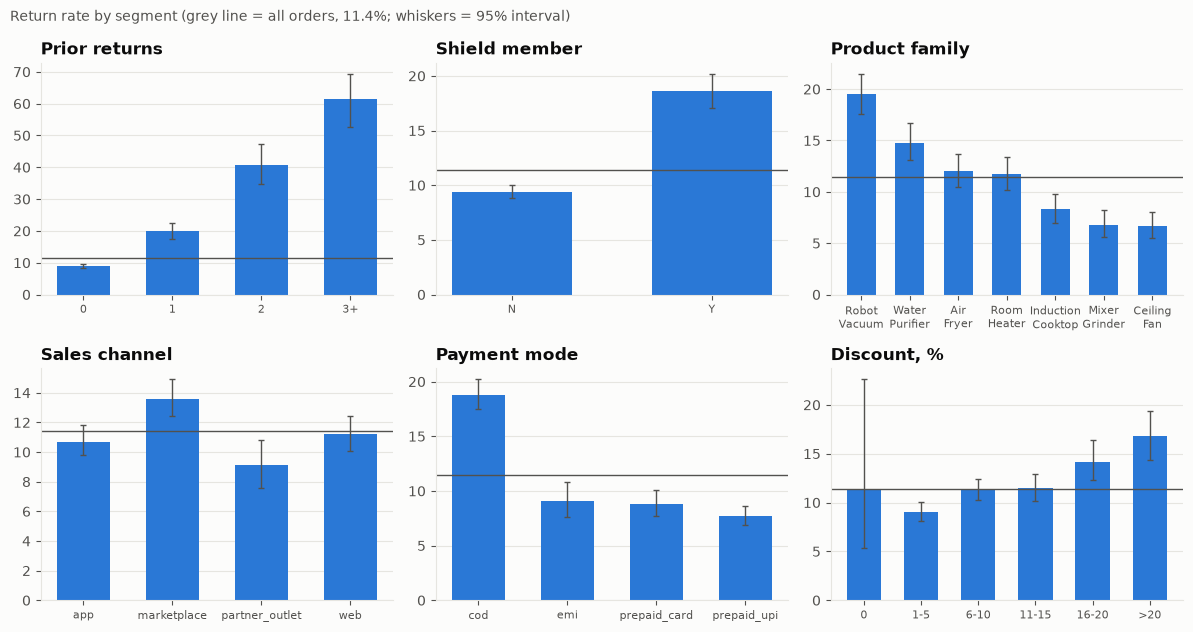

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6.4))
for ax, (col, title) in zip(axes.flat, [("prior_returns_c", "Prior returns"), ("shield_member", "Shield member"), ("family", "Product family"),
                                         ("sales_channel", "Sales channel"), ("payment_mode", "Payment mode"), ("discount_band", "Discount, %")]):
    t = tables[col]
    if col == "family":
        t = t.sort_values("rate", ascending=False)
        t.index = [s.replace(" ", "\n", 1) for s in t.index]
    rate_bars(t, title, ax=ax)
    ax.set_ylabel(""); ax.tick_params(axis="x", labelsize=8)
fig.suptitle(f"Return rate by segment (grey line = all orders, {BASE:.1%}; whiskers = 95% interval)", x=0.01, ha="left", color=INK2, fontsize=10)
fig.tight_layout(); fig.savefig(FIGURES_DIR / "02_drivers_grid.png", dpi=150); plt.show()

## 3 · Interactions

Shield x prior returns


mean         size      
shield_member        N      Y     N     Y
prior_returns_c                          
0                0.071  0.158  7098  2021
1                0.172  0.292   802   236
2                0.369  0.553   176    47
3+               0.564  0.826   101    23

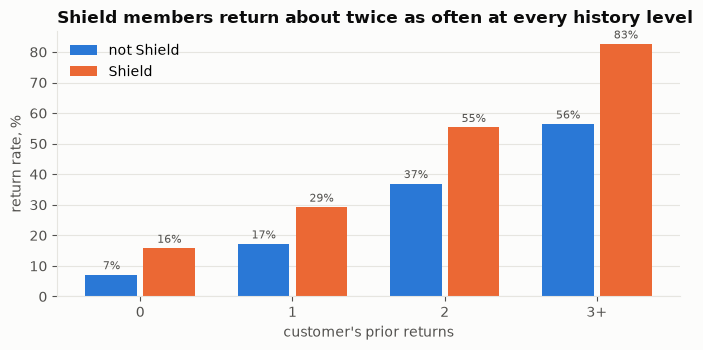

In [11]:
sp = tr.pivot_table(index="prior_returns_c", columns="shield_member", values="returned", aggfunc=["mean", "size"]).round(3)
print("Shield x prior returns"); display(sp)
fig, ax = plt.subplots(figsize=(7, 3.6))
x = np.arange(4); w = 0.38
for i, (flag, color, label) in enumerate([("N", BLUE, "not Shield"), ("Y", ORANGE, "Shield")]):
    vals = [tr[(tr.prior_returns_c == k) & (tr.shield_member == flag)].returned.mean() * 100 for k in ["0", "1", "2", "3+"]]
    bars = ax.bar(x + (i - 0.5) * w, vals, width=w - 0.04, color=color, label=label)
    ax.bar_label(bars, fmt="%.0f%%", fontsize=8, color=INK2, padding=2)
ax.set_xticks(x, ["0", "1", "2", "3+"]); ax.set_xlabel("customer's prior returns"); ax.set_ylabel("return rate, %")
ax.grid(axis="x", visible=False); ax.legend(loc="upper left")
ax.set_title("Shield members return about twice as often at every history level", loc="left")
fig.tight_layout(); fig.savefig(FIGURES_DIR / "02_shield_x_prior_returns.png", dpi=150); plt.show()

In [12]:
for idx, col in [("family", "sales_channel"), ("discount_band", "payment_mode"), ("family", "is_gift"), ("family", "shield_member")]:
    t = tr.pivot_table(index=idx, columns=col, values="returned", aggfunc="mean", observed=True).round(3)
    print(f"--- {idx} x {col} (return rate)"); display(t)

--- family x sales_channel (return rate)


sales_channel,app,marketplace,partner_outlet,web
family,,,,
Air Fryer,0.115,0.160,0.084,0.104
Ceiling Fan,0.057,0.096,0.037,0.062
Induction Cooktop,0.081,0.078,0.077,0.092
Mixer Grinder,0.056,0.076,0.062,0.077
Robot Vacuum,0.188,0.217,0.165,0.197
Room Heater,0.106,0.133,0.083,0.130
Water Purifier,0.147,0.186,0.127,0.119


--- discount_band x payment_mode (return rate)


payment_mode,cod,emi,prepaid_card,prepaid_upi
discount_band,,,,
0,0.250,0.000,0.133,0.043
1-5,0.142,0.069,0.076,0.062
6-10,0.182,0.104,0.081,0.076
11-15,0.210,0.072,0.088,0.074
16-20,0.235,0.116,0.097,0.098
>20,0.269,0.130,0.138,0.116


--- family x is_gift (return rate)


is_gift,N,Y
family,,
Air Fryer,0.113,0.217
Ceiling Fan,0.064,0.104
Induction Cooktop,0.078,0.156
Mixer Grinder,0.070,0.025
Robot Vacuum,0.190,0.250
Room Heater,0.110,0.204
Water Purifier,0.148,0.157


--- family x shield_member (return rate)


shield_member,N,Y
family,,
Air Fryer,0.096,0.209
Ceiling Fan,0.048,0.131
Induction Cooktop,0.064,0.148
Mixer Grinder,0.054,0.111
Robot Vacuum,0.174,0.267
Room Heater,0.098,0.188
Water Purifier,0.118,0.251


**Reading: interactions**
- **Shield × prior returns:** Shield roughly doubles the rate at every history level (7% → 16%, 17% → 29%, 37% → 55%, 56% → 83%). The two effects stack, so both are needed.
- **COD × discount:** the discount effect is stronger on COD (14% → 27%) than on UPI (6% → 12%). Roughly a doubling in both, which a logistic model on the log-odds scale handles without an explicit interaction.
- **Family × channel:** marketplace is highest within almost every family; partner outlet lowest. Consistent, no reversal.
- **Gift × family:** gifts return more for air fryers, room heaters and cooktops (~2×). Small groups (gift = 7% of orders), so it's a weak, noisy signal.

## 4 · Tenure
`signup_date` is after the order date for 19% of train orders (0.9% of test). Guard: negative tenure → flag + 0.

In [13]:
for d in (tr, te):
    days = (d.order_ts - d.signup_date).dt.days
    d["tenure_negative"] = (days < 0).astype(int)
    d["tenure_days"] = days.clip(lower=0)
tr["tenure_band"] = pd.cut(tr.tenure_days, [-1, 0, 90, 365, 730, 5000], labels=["0 / negative", "1-90", "91-365", "1-2 y", "> 2 y"])
display(rate_table(tr, "tenure_negative")); display(rate_table(tr, "tenure_band"))
print("single-field AUC: tenure_days", round(roc_auc_score(tr.returned, tr.tenure_days), 3),
      "| among non-negative only", round(roc_auc_score(tr[tr.tenure_negative == 0].returned, tr[tr.tenure_negative == 0].tenure_days), 3))
print("share negative: train", tr.tenure_negative.mean().round(3), "test", te.tenure_negative.mean().round(3))
tr["product_age_days"] = (tr.order_ts - tr.launch_date).dt.days
print("single-field AUC: product_age_days", round(roc_auc_score(tr.returned, tr.product_age_days), 3))

,orders,returns,rate,ci_low,ci_high,lift
tenure_negative,,,,,,
0,8505,974,0.115,0.108,0.121,1.002
1,1999,226,0.113,0.100,0.128,0.990


,orders,returns,rate,ci_low,ci_high,lift
tenure_band,,,,,,
0 / negative,2008,226,0.113,0.099,0.127,0.985
1-90,665,79,0.119,0.096,0.146,1.040
91-365,2063,226,0.110,0.097,0.124,0.959
1-2 y,2806,325,0.116,0.105,0.128,1.014
> 2 y,2962,344,0.116,0.105,0.128,1.017


single-field AUC: tenure_days 0.504 | among non-negative only 0.504
share negative: train 0.19 test 0.009
single-field AUC: product_age_days 0.512


**Reading: tenure has no signal, and it would behave differently at serve time.**
- Return rate is flat across tenure bands (11.0–11.9%) and for "signup after order" rows (11.3% vs 11.5%). Single-field AUC 0.504, the same as a coin flip.
- The negative-tenure flag has **PSI 0.60** between train (19%) and test (0.9%), the only shifted field in the pack.
- Product age at order: AUC 0.51, weak.

**Decision: drop tenure entirely** (no guard needed, and the service no longer needs `signup_date`). Product age stays a weak candidate for the Phase 4 ablation.

## 5 · Stability over time and season

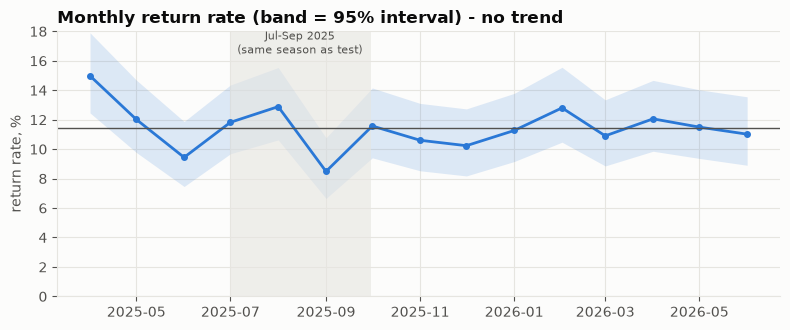

month,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06
orders,661.000,674.000,678.000,736.000,714.000,707.000,700.000,698.000,684.000,719.000,664.000,743.000,705.000,722.000,699.000
returns,99.000,81.000,64.000,87.000,92.000,60.000,81.000,74.000,70.000,81.000,85.000,81.000,85.000,83.000,77.000
rate,0.150,0.120,0.094,0.118,0.129,0.085,0.116,0.106,0.102,0.113,0.128,0.109,0.121,0.115,0.110
ci_low,0.125,0.098,0.075,0.097,0.106,0.066,0.094,0.085,0.082,0.092,0.105,0.089,0.099,0.094,0.089
ci_high,0.179,0.147,0.119,0.144,0.155,0.108,0.142,0.131,0.127,0.138,0.156,0.133,0.147,0.140,0.136


In [14]:
tr["month"] = tr.order_ts.dt.to_period("M")
monthly = tr.groupby("month").returned.agg(orders="size", returns="sum")
monthly["rate"] = monthly.returns / monthly.orders
monthly["ci_low"], monthly["ci_high"] = wilson(monthly.returns, monthly.orders)
fig, ax = plt.subplots(figsize=(8, 3.4))
xs = monthly.index.to_timestamp()
ax.fill_between(xs, monthly.ci_low * 100, monthly.ci_high * 100, color=BLUE, alpha=0.15, lw=0)
ax.plot(xs, monthly.rate * 100, color=BLUE, lw=2, marker="o", ms=4)
ax.axhline(BASE * 100, color=INK2, lw=1)
ax.axvspan(pd.Timestamp("2025-07-01"), pd.Timestamp("2025-09-30"), color=GRID, alpha=0.6, lw=0)
ax.annotate("Jul-Sep 2025\n(same season as test)", xy=(pd.Timestamp("2025-08-15"), 16.5), ha="center", color=INK2, fontsize=8)
ax.set_ylabel("return rate, %"); ax.set_ylim(0, 18)
ax.set_title("Monthly return rate (band = 95% interval) - no trend", loc="left")
fig.tight_layout(); fig.savefig(FIGURES_DIR / "02_monthly_return_rate.png", dpi=150); plt.show()
monthly.round(3).T

In [15]:
tr["festive"] = tr.month.isin([pd.Period("2025-10"), pd.Period("2025-11")]).map({True: "Oct-Nov 2025", False: "other months"})
tr["season_q"] = np.where(tr.month.dt.month.isin([7, 8, 9]), "Jul-Sep", "other")
display(rate_table(tr, "festive")); display(rate_table(tr, "season_q"))
# Do the main drivers keep their direction over time? Rate by quarter for the top segments.
tr["quarter"] = tr.order_ts.dt.to_period("Q")
for col in ["prior_returns_c", "shield_member", "metro", "family"]:
    print(f"--- {col} by quarter"); display(tr.pivot_table(index=col, columns="quarter", values="returned", aggfunc="mean", observed=True).round(3))

,orders,returns,rate,ci_low,ci_high,lift
festive,,,,,,
Oct-Nov 2025,1398,155,0.111,0.095,0.128,0.971
other months,9106,1045,0.115,0.108,0.121,1.005


,orders,returns,rate,ci_low,ci_high,lift
season_q,,,,,,
Jul-Sep,2157,239,0.111,0.098,0.125,0.970
other,8347,961,0.115,0.108,0.122,1.008


--- prior_returns_c by quarter


quarter,2025Q2,2025Q3,2025Q4,2026Q1,2026Q2
prior_returns_c,,,,,
0,0.095,0.081,0.091,0.092,0.093
1,0.243,0.201,0.172,0.208,0.171
2,0.366,0.396,0.342,0.465,0.458
3+,0.619,0.639,0.542,0.545,0.714


--- shield_member by quarter


quarter,2025Q2,2025Q3,2025Q4,2026Q1,2026Q2
shield_member,,,,,
N,0.102,0.094,0.088,0.097,0.089
Y,0.188,0.172,0.184,0.181,0.205


--- metro by quarter


quarter,2025Q2,2025Q3,2025Q4,2026Q1,2026Q2
metro,,,,,
metro,0.101,0.078,0.068,0.098,0.083
non-metro,0.131,0.127,0.128,0.125,0.133


--- family by quarter


quarter,2025Q2,2025Q3,2025Q4,2026Q1,2026Q2
family,,,,,
Air Fryer,0.143,0.134,0.121,0.094,0.107
Ceiling Fan,0.081,0.058,0.051,0.071,0.072
Induction Cooktop,0.078,0.059,0.078,0.095,0.106
Mixer Grinder,0.074,0.052,0.070,0.066,0.076
Robot Vacuum,0.156,0.212,0.205,0.221,0.182
Room Heater,0.129,0.096,0.098,0.128,0.133
Water Purifier,0.178,0.159,0.134,0.140,0.126


**Reading: stable over time, no season effect.**
- No trend across 15 months. The Oct–Nov 2025 festive window (11.1%) and the Jul–Sep season (11.1%) match the other months (11.5%), so **no festive/season feature is needed**, and Jul–Sep 2025 is a fair stand-in for the test quarter.
- The main drivers keep their direction every quarter (prior returns, Shield, metro gap, family order).
- Some family-level drift: air fryer 14.3% → 10.7%, water purifier 17.8% → 12.6%, induction cooktop 7.8% → 10.6% from 2025-Q2 to 2026-Q2. Validating on the latest months (plan Phase 4) captures this. Recency weighting is a Phase 4 option to test, not a default.

## 6 · Train vs test shift (population stability index)
PSI < 0.1 = stable, 0.1–0.25 = watch, > 0.25 = shifted.

In [16]:
te["discount_band"] = pd.cut(te.discount_pct, [-0.1, 0, 5, 10, 15, 20, 100], labels=["0", "1-5", "6-10", "11-15", "16-20", ">20"])
te["value_band"] = pd.cut(te.order_value_inr, pd.qcut(tr.order_value_inr, 5, retbins=True)[1], labels=["Q1 low", "Q2", "Q3", "Q4", "Q5 high"], include_lowest=True)
te["prior_returns_c"] = te.customer_prior_returns.clip(upper=3).astype(str).replace({"3": "3+"})
te["prior_orders_c"] = te.customer_prior_orders.clip(upper=4).astype(str).replace({"4": "4+"})
te["promised_band"] = pd.cut(te.promised_delivery_days, [0, 3, 5, 7, 12], labels=["1-3", "4-5", "6-7", "8-12"])
def psi(col):
    a = tr[col].astype(str).value_counts(normalize=True); b = te[col].astype(str).value_counts(normalize=True)
    idx = a.index.union(b.index); a = a.reindex(idx).fillna(1e-4); b = b.reindex(idx).fillna(1e-4)
    return float(((b - a) * np.log(b / a)).sum())
cols = ["sales_channel", "payment_mode", "family", "sku", "city", "metro", "shield_member", "discount_band", "value_band",
        "prior_returns_c", "prior_orders_c", "promised_band", "is_gift", "qty", "address_missing", "tenure_negative"]
pd.Series({c: psi(c) for c in cols}).round(4).sort_values(ascending=False).to_frame("PSI train->test")

,PSI train->test
tenure_negative,0.5998
city,0.0119
sku,0.0082
prior_orders_c,0.0035
promised_band,0.0022
payment_mode,0.0018
sales_channel,0.0016
qty,0.0013
value_band,0.0010
prior_returns_c,0.0009


**Reading: almost no shift.** Every dispatch-time field has PSI < 0.012 (city 0.012, SKU 0.008, everything else < 0.004). The only shifted field is the negative-tenure flag (0.60), which is now dropped. The test quarter looks like the training data.

## 7 · Order value by family → margin input for Phase 5
Calls beat holds whenever the margin lost on a cancelled good order exceeds **₹375** (₹45 ÷ 0.12). Which orders clear that at 15 / 25 / 35% margin?

In [17]:
BREAK_EVEN = CALL_COST_INR / HOLD_CANCEL_RATE
ov = tr.groupby("family").order_value_inr.describe(percentiles=[0.1, 0.5]).round(0)[["count", "min", "10%", "50%", "max"]]
for m in (0.15, 0.25, 0.35):
    ov[f"clears ₹{BREAK_EVEN:.0f} at {int(m * 100)}%"] = tr.groupby("family").order_value_inr.apply(lambda s: (s * m > BREAK_EVEN).mean()).round(3)
overall = {f"{int(m * 100)}%": round(float((tr.order_value_inr * m > BREAK_EVEN).mean()), 3) for m in (0.15, 0.25, 0.35)}
print(f"break-even margin ₹{BREAK_EVEN:.0f} | median order value ₹{tr.order_value_inr.median():,.0f} | share of all orders clearing it: {overall}")
ov.sort_values("50%")

break-even margin ₹375 | median order value ₹4,440 | share of all orders clearing it: {'15%': 0.836, '25%': 0.998, '35%': 1.0}


,count,min,10%,50%,max,clears ₹375 at 15%,clears ₹375 at 25%,clears ₹375 at 35%
family,,,,,,,,
Room Heater,1525.0,880.0,1779.0,2324.0,6611.0,0.355,0.986,0.999
Induction Cooktop,1476.0,1415.0,2111.0,2789.0,8015.0,0.648,0.999,1.000
Ceiling Fan,1531.0,1540.0,2463.0,3254.0,9352.0,0.875,1.000,1.000
Mixer Grinder,1451.0,1727.0,2815.0,3759.0,10796.0,0.980,1.000,1.000
Air Fryer,1516.0,2080.0,4523.0,5979.0,17371.0,0.999,1.000,1.000
Water Purifier,1451.0,7200.0,10559.0,13799.0,40091.0,1.000,1.000,1.000
Robot Vacuum,1554.0,11791.0,15311.0,20239.0,58802.0,1.000,1.000,1.000


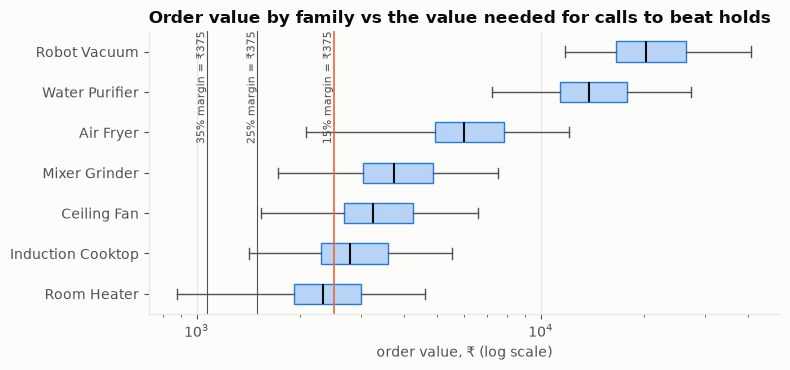

In [18]:
fams = tr.groupby("family").order_value_inr.median().sort_values().index
fig, ax = plt.subplots(figsize=(8, 3.8))
data = [tr.loc[tr.family == f, "order_value_inr"] for f in fams]
bp = ax.boxplot(data, orientation="horizontal", tick_labels=list(fams), widths=0.5, showfliers=False, patch_artist=True,
                medianprops={"color": INK, "lw": 1.5}, whiskerprops={"color": INK2}, capprops={"color": INK2})
for b in bp["boxes"]: b.set_facecolor("#b7d3f6"); b.set_edgecolor(BLUE)
for m, ls in [(0.15, "-"), (0.25, "-"), (0.35, "-")]:
    ax.axvline(BREAK_EVEN / m, color=ORANGE if m == 0.15 else INK2, lw=1.2 if m == 0.15 else 0.8)
    ax.annotate(f"{int(m*100)}% margin = ₹375", xy=(BREAK_EVEN / m, 1.0), xycoords=("data", "axes fraction"), rotation=90, va="top", ha="right", fontsize=8, color=INK2)
ax.set_xscale("log"); ax.set_xlabel("order value, ₹ (log scale)"); ax.grid(axis="y", visible=False)
ax.set_title("Order value by family vs the value needed for calls to beat holds", loc="left")
fig.tight_layout(); fig.savefig(FIGURES_DIR / "02_order_value_vs_breakeven.png", dpi=150); plt.show()

**Reading: the margin question is mostly settled, except for cheap families at low margins.**
- Median order ₹4,440. At **25% or 35% margin, 99.8–100% of orders clear ₹375**, so calls beat holds for essentially every order.
- At **15% margin**, 83.6% of orders clear it. Room heaters (median ₹2,324; only 35% clear) and induction cooktops (₹2,789; 65%) fall short. **At thin margins, the hold-vs-call conclusion for these two families needs a per-family line in the memo.** Phase 5 sets the assumption.

## 8 · Stakeholder claims

In [19]:
sh = tr.shield_member == "Y"
print(f"Meenal - 'most returns are Shield': Shield = {sh.mean():.1%} of orders, {tr[sh].returned.sum() / tr.returned.sum():.1%} of returns; "
      f"return rate {tr[sh].returned.mean():.1%} vs {tr[~sh].returned.mean():.1%} ({tr[sh].returned.mean() / tr[~sh].returned.mean():.1f}x)")
print(f"Ritu - '95% accuracy': predicting 'no return' for every order scores {1 - BASE:.1%}")
spring = tr[tr.month.isin([pd.Period(m) for m in ["2026-03", "2026-04", "2026-05"]])].groupby("month").returned.mean().round(3)
print("Spring 2026 call pilot - monthly return rate:", {str(k): v for k, v in spring.items()}, f"vs overall {BASE:.3f}")

Meenal - 'most returns are Shield': Shield = 22.2% of orders, 36.1% of returns; return rate 18.6% vs 9.4% (2.0x)
Ritu - '95% accuracy': predicting 'no return' for every order scores 88.6%
Spring 2026 call pilot - monthly return rate: {'2026-03': 0.109, '2026-04': 0.121, '2026-05': 0.115} vs overall 0.114


**Reading:**
- **Meenal**: Shield = 22.2% of orders and **36.1% of returns**, not "most". But Shield customers return **2.0×** as often (18.6% vs 9.4%).
- **Ritu**: "no order returns" already scores **88.6%** accuracy, so accuracy can't be the bar.
- **Spring 2026 pilot**: Mar 10.9%, Apr 12.1%, May 11.5% (deduplicated) vs 11.4% overall. No visible dip; we use the policy's 35%.

## 9 · Summary → decisions

| # | Finding | Decision |
|---|---|---|
| 1 | Pincode region is `440` for all 12 non-metro cities; only 8.4% of 440 orders are from Nagpur customers | **Drop region**; use `city` (or `metro`), passed with the order |
| 2 | Non-metro gap (+4.4 pts) holds within every channel, family, Shield and history group | Real effect; `city` vs `metro` chosen in Phase 4 |
| 3 | Strong drivers: payment mode, promised days, prior returns, Shield, prior orders, family | Core feature set |
| 4 | Medium: discount, order value, city | Include |
| 5 | Warranty = family restated; value-vs-list = discount restated | Exclude (redundant) |
| 6 | No signal: hour, weekday, festive window, season, note template, tenure | Exclude hour/weekday/festive/tenure; notes only via ablation |
| 7 | Weak: channel, tier, qty, gift, address missing, product age | Candidates; kept or dropped by Phase 4 ablation |
| 8 | Tenure: no signal and PSI 0.60 train→test | **Drop** (service no longer needs `signup_date`) |
| 9 | Shield and prior returns stack (Shield ≈ 2× at every level) | Both features; Shield ablation still runs (snapshot risk) |
| 10 | Stable over time; train ≈ test (PSI < 0.012); some family drift | Time-based validation as planned; test recency weighting |
| 11 | 99.8% of orders clear ₹375 at 25% margin; at 15%, room heaters / cooktops don't | Phase 5 margin decision with a per-family line |

## 10 · Follow-ups before Phase 3

Requested at Phase 2 sign-off:

| § | Check |
|---|---|
| 10a | Holdout discipline: re-run the single-field ranking on walk-forward folds **ending by Mar 2026** (Apr–Jun 2026 is reserved for the final estimate) |
| 10b | City confound: does the metro gap survive within payment mode and promised-delivery bands? |
| 10c | Order value redundancy: which single representation of price/value? |
| 10d | Rare flags (< ~10% of orders): effect size with a 95% interval instead of single-field AUC |
| 10e | Margin: risk level above which calls beat holds for the cheapest families at 15% margin |

### 10a · Holdout discipline
The §2 ranking was scored on Apr–Jun 2026, which is the final holdout. Same check on three expanding walk-forward folds that end by Mar 2026 (encoding fitted on all earlier months only).

In [20]:
FOLDS = [("2025-07-01", "2025-10-01"), ("2025-10-01", "2026-01-01"), ("2026-01-01", "2026-04-01")]
FOLD_NAMES = ["Jul-Sep 25", "Oct-Dec 25", "Jan-Mar 26"]
tr["tenure_band_s"] = tr.tenure_band.astype(str)
def fold_auc(col, start, end):
    past = tr.order_ts < start
    val = (tr.order_ts >= start) & (tr.order_ts < end)
    means = tr[past].groupby(col, observed=True).returned.mean()
    score = tr.loc[val, col].map(means).astype(float).fillna(tr[past].returned.mean())
    return roc_auc_score(tr.loc[val, "returned"], score)
fields = DRIVERS + ["city", "sku", "note_cat", "tenure_band_s"]
wf = pd.DataFrame({n: {c: fold_auc(c, a, b) for c in fields} for n, (a, b) in zip(FOLD_NAMES, FOLDS)})
wf["min"] = wf.min(axis=1); wf["max"] = wf[FOLD_NAMES].max(axis=1)
wf["holdout Apr-Jun 26 (seen in §2)"] = rank.reindex(wf.index)
wf.round(3).sort_values("min", ascending=False)

,Jul-Sep 25,Oct-Dec 25,Jan-Mar 26,min,max,holdout Apr-Jun 26 (seen in §2)
family,0.648,0.624,0.616,0.616,0.648,0.588
sku,0.611,0.630,0.611,0.611,0.630,0.583
payment_mode,0.624,0.596,0.601,0.596,0.624,0.639
promised_band,0.593,0.598,0.591,0.591,0.598,0.614
value_band,0.622,0.602,0.589,0.589,0.622,0.543
prior_returns_c,0.635,0.581,0.607,0.581,0.635,0.599
shield_member,0.568,0.582,0.572,0.568,0.582,0.599
prior_orders_c,0.628,0.566,0.566,0.566,0.628,0.597
warranty_months,0.579,0.570,0.565,0.565,0.579,0.559
city,0.544,0.574,0.542,0.542,0.574,0.552


<!-- 10a reading -->
**Reading: the Phase 2 drops are safe on every period, not just on the holdout.** The fields dropped for lack of signal stay at coin-flip level on **all three** walk-forward folds: tenure 0.49–0.51, hour 0.48–0.51, weekday 0.49–0.51, note present 0.47–0.51, note template 0.50–0.53, address missing 0.49–0.52, tier 0.47–0.52, qty 0.50–0.51. Warranty and value-vs-list were dropped for redundancy, not for signal, so the holdout didn't drive them either.

The strong drivers are strong on every fold (family 0.62–0.65, payment 0.60–0.62, promised days 0.59–0.60, prior returns 0.58–0.64, Shield 0.57–0.58, prior orders 0.57–0.63).

**Rule from here on:** every selection decision (ablations, city vs metro, recency weighting, hyperparameters, LR vs HGB) uses these walk-forward folds, ending Mar 2026. **Apr–Jun 2026 is used once, at the end, for the expected-score estimate.** The §2 ranking looked at Apr–Jun; it is kept for transparency, but no further decision uses it.

### 10b · City confound - metro gap within payment mode and promised-delivery bands

In [21]:
tr["pay2"] = np.where(tr.payment_mode == "cod", "COD", "prepaid")
def strat_gap(by):
    g = tr.groupby(by + ["metro"], observed=True).returned.agg(["sum", "size"]).unstack("metro")
    rate_m, rate_n = g[("sum", "metro")] / g[("size", "metro")], g[("sum", "non-metro")] / g[("size", "non-metro")]
    n_m, n_n = g[("size", "metro")], g[("size", "non-metro")]
    out = pd.DataFrame({"metro": rate_m, "non-metro": rate_n, "gap_pts": (rate_n - rate_m) * 100, "orders": n_m + n_n})
    # Mantel-Haenszel-weighted average gap with a 95% interval
    w = n_m * n_n / (n_m + n_n)
    d = rate_n - rate_m
    var = rate_m * (1 - rate_m) / n_m + rate_n * (1 - rate_n) / n_n
    mh = (w * d).sum() / w.sum(); se = np.sqrt((w ** 2 * var).sum()) / w.sum()
    return out.round(3), mh * 100, 1.96 * se * 100
raw = tr.groupby("metro").returned.mean()
print(f"raw gap: {(raw['non-metro'] - raw['metro']) * 100:.1f} pts")
for by in (["pay2"], ["promised_band"], ["pay2", "promised_band"], ["pay2", "promised_band", "family"]):
    t, mh, ci = strat_gap(by)
    print(f"--- within {' x '.join(by)}: adjusted gap {mh:.1f} pts (95% interval ±{ci:.1f})")
    if len(by) < 3: display(t)
mix = pd.crosstab(tr.metro, [tr.pay2], normalize="index").round(3)
mix["promised days (mean)"] = tr.groupby("metro").promised_delivery_days.mean().round(2)
print("payment and delivery-promise mix by tier:"); display(mix)

raw gap: 4.3 pts
--- within pay2: adjusted gap 4.4 pts (95% interval ±1.2)


,metro,non-metro,gap_pts,orders
pay2,,,,
COD,0.143,0.212,6.881,3152
prepaid,0.060,0.094,3.318,7352


--- within promised_band: adjusted gap 2.1 pts (95% interval ±1.3)


,metro,non-metro,gap_pts,orders
promised_band,,,,
1-3,0.076,0.076,-0.079,2300
4-5,0.086,0.101,1.531,4207
6-7,0.105,0.152,4.692,2900
8-12,0.115,0.194,7.898,1097


--- within pay2 x promised_band: adjusted gap 2.2 pts (95% interval ±1.3)


metro  non-metro  gap_pts  orders
pay2    promised_band                                   
COD     1-3            0.120      0.155    3.499     698
        4-5            0.143      0.165    2.244    1273
        6-7            0.205      0.242    3.685     864
        8-12           0.156      0.323   16.656     317
prepaid 1-3            0.057      0.041   -1.587    1602
        4-5            0.060      0.073    1.253    2934
        6-7            0.062      0.115    5.248    2036
        8-12           0.097      0.143    4.543     780

--- within pay2 x promised_band x family: adjusted gap 1.9 pts (95% interval ±1.3)
payment and delivery-promise mix by tier:


pay2,COD,prepaid,promised days (mean)
metro,,,
metro,0.304,0.696,3.97
non-metro,0.298,0.702,5.56


**Reading: city is partly a proxy for delivery time, not for COD.**
- **Payment mode explains none of it:** the COD share is the same in both tiers (30.4% vs 29.8%), and the gap within payment mode stays at **4.4 pts (±1.2)**.
- **Delivery promise explains about half:** non-metro orders are promised 5.6 days on average vs 4.0 in metros. Within promised-day bands the gap falls to **2.1 pts (±1.3)**, and in the 1–3 day band it is **zero**. The gap grows with the promise (+1.5 at 4–5 days, +4.7 at 6–7, +7.9 at 8–12).
- Adjusting for payment × promise × family leaves **1.9 pts (±1.3)**: a small residual location effect survives, but its interval nearly touches zero.

**Decision:** keep location in the Phase 4 ablation (`metro` preferred over `city` if their walk-forward scores are within noise). Reasons must word it neutrally and honestly, e.g. *"Orders delivered to this area are returned more often, especially with longer delivery times"*, not as a statement about the customer.

### 10c · Order value redundancy
`order_value_inr = list_price × qty × (1 − discount)`. Does value carry anything once family and discount are known?

In [22]:
print("within-family return rate by SKU tier (= list-price level inside the family):")
display(tr.pivot_table(index="family", columns="tier", values="returned", aggfunc="mean").round(3)[["Lite", "Pro", "Max"]])
tr["value_tertile_in_family"] = tr.groupby("family").order_value_inr.transform(lambda s: pd.qcut(s, 3, labels=["low", "mid", "high"]))
print("within-family return rate by order-value tertile:")
display(tr.pivot_table(index="family", columns="value_tertile_in_family", values="returned", aggfunc="mean", observed=True).round(3))
print("same, discount <= 10% only (removes the discount path):")
display(tr[tr.discount_pct <= 10].pivot_table(index="family", columns="value_tertile_in_family", values="returned", aggfunc="mean", observed=True).round(3))

within-family return rate by SKU tier (= list-price level inside the family):


tier,Lite,Pro,Max
family,,,
Air Fryer,0.121,0.122,0.116
Ceiling Fan,0.061,0.060,0.080
Induction Cooktop,0.076,0.079,0.092
Mixer Grinder,0.074,0.065,0.064
Robot Vacuum,0.168,0.209,0.211
Room Heater,0.106,0.115,0.130
Water Purifier,0.136,0.158,0.150


within-family return rate by order-value tertile:


value_tertile_in_family,low,mid,high
family,,,
Air Fryer,0.118,0.124,0.118
Ceiling Fan,0.058,0.067,0.075
Induction Cooktop,0.073,0.088,0.087
Mixer Grinder,0.076,0.074,0.052
Robot Vacuum,0.184,0.212,0.190
Room Heater,0.119,0.114,0.117
Water Purifier,0.138,0.163,0.144


same, discount <= 10% only (removes the discount path):


value_tertile_in_family,low,mid,high
family,,,
Air Fryer,0.104,0.120,0.095
Ceiling Fan,0.046,0.062,0.066
Induction Cooktop,0.060,0.070,0.085
Mixer Grinder,0.079,0.055,0.049
Robot Vacuum,0.155,0.171,0.189
Room Heater,0.104,0.107,0.117
Water Purifier,0.108,0.150,0.149


**Reading: order value adds nothing once family and discount are known.** Within each family, return rates are flat across SKU tiers and across order-value tertiles (e.g. air fryer 11.8 / 12.4 / 11.8%; room heater 11.9 / 11.4 / 11.7%). With discount held low, a few families show a slight rise with price (robot vacuum 15.5% → 18.9%), but the groups are small and the pattern isn't consistent (mixer grinder falls).

**Decision: one price representation = `family` + `discount_pct`.** `order_value_inr` is **not** a model feature (it is list price × qty × (1 − discount), so it would overlap family and discount in a logistic model and split one effect across several reasons). SKU tier stays an ablation candidate to capture the within-family price level. Order value is still used for the ₹ economics (margin, refund size).

### 10d · Rare flags - effect size with a 95% interval

In [23]:
def effect(flag_name, mask):
    a, b = tr[mask].returned, tr[~mask].returned
    pa, pb = a.mean(), b.mean()
    diff = pa - pb; se = np.sqrt(pa * (1 - pa) / len(a) + pb * (1 - pb) / len(b))
    rr = pa / pb; se_log = np.sqrt((1 - pa) / (pa * len(a)) + (1 - pb) / (pb * len(b)))
    return {"orders": len(a), "share": round(len(a) / len(tr), 3), "rate_flag": round(pa, 3), "rate_rest": round(pb, 3),
            "diff_pts": round(diff * 100, 1), "diff_95%": f"[{(diff - 1.96 * se) * 100:.1f}, {(diff + 1.96 * se) * 100:.1f}]",
            "risk_ratio": round(rr, 2), "rr_95%": f"[{np.exp(np.log(rr) - 1.96 * se_log):.2f}, {np.exp(np.log(rr) + 1.96 * se_log):.2f}]"}
rare = pd.DataFrame({
    "gift": effect("gift", tr.is_gift == "Y"),
    "address missing": effect("address missing", tr.address_missing == 1),
    "qty = 2": effect("qty = 2", tr.qty == 2),
    "discount = 0": effect("discount = 0", tr.discount_pct == 0),
    "promised 8-12 days": effect("promised 8-12", tr.promised_delivery_days >= 8),
    "note 'other'": effect("note other", tr.note_cat == "other"),
}).T
rare

,orders,share,rate_flag,rate_rest,diff_pts,diff_95%,risk_ratio,rr_95%
gift,726,0.069,0.165,0.11,5.5,"[2.7, 8.3]",1.5,"[1.26, 1.78]"
address missing,848,0.081,0.125,0.113,1.2,"[-1.1, 3.5]",1.1,"[0.92, 1.33]"
qty = 2,623,0.059,0.103,0.115,-1.2,"[-3.7, 1.2]",0.89,"[0.70, 1.13]"
discount = 0,53,0.005,0.113,0.114,-0.1,"[-8.7, 8.4]",0.99,"[0.47, 2.11]"
promised 8-12 days,1097,0.104,0.187,0.106,8.1,"[5.7, 10.5]",1.77,"[1.54, 2.03]"
note 'other',4,0.0,0.25,0.114,13.6,"[-28.9, 56.0]",2.19,"[0.40, 11.96]"


In [24]:
# Is the gift effect stable over time, and does it survive within family / payment?
print("gift effect by half-year (rate gift vs not):")
tr["half"] = np.where(tr.order_ts < "2025-10-01", "Apr-Sep 25", "Oct 25-Mar 26")
sel = tr.order_ts < "2026-04-01"   # holdout discipline: Apr-Jun 2026 is not used for selection
display(tr[sel].pivot_table(index="half", columns="is_gift", values="returned", aggfunc=["mean", "size"]).round(3))
t, mh, ci = None, None, None
g = tr[sel].groupby(["family", "pay2", "is_gift"]).returned.agg(["sum", "size"]).unstack("is_gift").dropna()
ry, rn = g[("sum", "Y")] / g[("size", "Y")], g[("sum", "N")] / g[("size", "N")]
w = g[("size", "Y")] * g[("size", "N")] / (g[("size", "Y")] + g[("size", "N")])
var = ry * (1 - ry) / g[("size", "Y")] + rn * (1 - rn) / g[("size", "N")]
mh = ((w * (ry - rn)).sum() / w.sum()) * 100; ci = 1.96 * np.sqrt((w ** 2 * var).sum()) / w.sum() * 100
print(f"gift gap adjusted for family x payment: {mh:.1f} pts (95% interval ±{ci:.1f}); raw {((tr[sel & (tr.is_gift == 'Y')].returned.mean() - tr[sel & (tr.is_gift == 'N')].returned.mean()) * 100):.1f} pts (Apr 2025 - Mar 2026)")

gift effect by half-year (rate gift vs not):


mean         size     
is_gift            N      Y     N    Y
half                                  
Apr-Sep 25     0.111  0.177  3877  293
Oct 25-Mar 26  0.108  0.170  3908  300

gift gap adjusted for family x payment: 6.5 pts (95% interval ±3.0); raw 6.4 pts (Apr 2025 - Mar 2026)


**Reading: rare flags judged by effect size (95% intervals)**
| Flag | Share | Effect | Verdict |
|---|---|---|---|
| **Gift** | 6.9% (726) | **+5.5 pts [2.7, 8.3], risk ratio 1.50 [1.26, 1.78]**; same in both training halves (17.7% vs 11.1%, 17.0% vs 10.8%); +6.5 pts (±3.0) after adjusting for family × payment (Apr 2025 – Mar 2026) | **Serious candidate**: real, stable effect that single-field AUC hid because only 7% of orders are gifts |
| Address missing | 8.1% | +1.2 pts [−1.1, 3.5] | No evidence of an effect |
| Qty = 2 | 5.9% | −1.2 pts [−3.7, 1.2] | No evidence |
| Discount = 0 | 0.5% (53) | −0.1 pts [−8.7, 8.4] | Too rare to tell; covered by `discount_pct` |
| Note `other` | 4 orders | - | Too rare; not a feature |
| *(reference)* promised 8–12 days | 10.4% | +8.1 pts [5.7, 10.5] | Strong, already in the core via `promised_delivery_days` |

### 10e · Margin: when do calls beat holds for the cheapest families?
Per order, with margin m = 15% of order value, C = ₹1,150, p = return probability:
- Call net = 0.35·p·(C + m) − 45 *(a prevented return also keeps the sale's margin)*; conservative version drops the margin term.
- Hold net = 0.12·p·C − 0.12·(1 − p)·m.
- **Crossover p×**: the risk above which call ≥ hold. **Calling is only worth doing above p_call** (call net > 0). If p× < p_call, then *for every order worth acting on, calls beat holds*.

In [25]:
C, CALL, PREV, CANCEL = 1150, CALL_COST_INR, 0.35, HOLD_CANCEL_RATE
def crossover(m, keep_margin=True):
    # call - hold = PREV*p*(C + k*m) - CALL - CANCEL*p*C + CANCEL*(1-p)*m, with k = 1 (true) or 0 (conservative)
    k = 1.0 if keep_margin else 0.0
    slope = PREV * (C + k * m) - CANCEL * C - CANCEL * m
    const = CANCEL * m - CALL
    # call - hold is linear in p and always > 0 at p = 1 (>= ₹219.5), so:
    # const >= 0 -> calls win at every p; otherwise the crossover is -const / slope (slope > 0 then)
    m = np.asarray(m, dtype=float); slope = np.broadcast_to(slope, m.shape); const = np.broadcast_to(const, m.shape)
    return np.where(const >= 0, 0.0, -const / np.where(slope > 0, slope, np.inf))
def p_call(m, keep_margin=True):
    return CALL / (PREV * (C + (m if keep_margin else 0)))
rows = []
for fam, d in tr.groupby("family"):
    m = 0.15 * d.order_value_inr
    rows.append({"family": fam, "median value": round(d.order_value_inr.median()),
                 "p_call (conservative)": round(p_call(0, False), 3),
                 "p_call (true, median order)": round(float(p_call(m.median())), 3),
                 "crossover p× median order": round(float(crossover(m.median())), 3),
                 "crossover p× cheapest order": round(float(crossover(m.min())), 3),
                 "crossover p× cheapest, conservative": round(float(crossover(m.min(), False)), 3),
                 "share where p× < p_call (true)": round(float((crossover(m) < p_call(m)).mean()), 3),
                 "share where p× < p_call (conservative)": round(float((crossover(m, False) < p_call(0, False)).mean()), 3)})
margin_tbl = pd.DataFrame(rows).set_index("family").sort_values("median value")
margin_tbl.to_csv(FIGURES_DIR.parent / "margin_crossover_15pct.csv")   # evidence table (aggregates only)
margin_tbl

,median value,p_call (conservative),"p_call (true, median order)",crossover p× median order,crossover p× cheapest order,"crossover p× cheapest, conservative",share where p× < p_call (true),share where p× < p_call (conservative)
family,,,,,,,,
Room Heater,2324,0.112,0.086,0.009,0.099,0.117,1.0,0.999
Induction Cooktop,2789,0.112,0.082,0.000,0.062,0.082,1.0,1.000
Ceiling Fan,3254,0.112,0.078,0.000,0.054,0.073,1.0,1.000
Mixer Grinder,3759,0.112,0.075,0.000,0.043,0.060,1.0,1.000
Air Fryer,5979,0.112,0.063,0.000,0.023,0.033,1.0,1.000
Water Purifier,13799,0.112,0.040,0.000,0.000,0.000,1.0,1.000
Robot Vacuum,20239,0.112,0.031,0.000,0.000,0.000,1.0,1.000


In [26]:
for mrg in (0.10, 0.15, 0.25):
    m = mrg * tr.order_value_inr
    print(f"margin {int(mrg*100)}%: orders where calls beat holds for every p worth calling - true {(crossover(m) < p_call(m)).mean():.1%}, "
          f"conservative {(crossover(m, False) < p_call(0, False)).mean():.1%}; worst-case crossover p× {float(crossover(m.min(), False)):.3f}")

margin 10%: orders where calls beat holds for every p worth calling - true 100.0%, conservative 99.8%; worst-case crossover p× 0.136
margin 15%: orders where calls beat holds for every p worth calling - true 100.0%, conservative 100.0%; worst-case crossover p× 0.117
margin 25%: orders where calls beat holds for every p worth calling - true 100.0%, conservative 100.0%; worst-case crossover p× 0.078


**Reading: calls beat holds for every order worth acting on.**
- Even for the cheapest families at **15% margin**, the risk level where a call starts to beat a hold (p×) is **below** the risk level where calling is worth doing at all (p_call). For a median room heater p× is 0.9% vs p_call 8.6%; for a median cooktop p× is 0%.
- Worst case, the single cheapest room heater (₹880): p× = 9.9% vs p_call = 10.0% (true accounting); 11.7% vs 11.2% if we ignore the margin a prevented return keeps. That leaves a sliver of 1–2 orders, before counting any hold handling or goodwill cost.
- Across all orders, at 10%, 15% and 25% margin: 100% (true) and 99.8–100% (conservative) of orders have calls beating holds wherever calling pays.

**Updated finding: for every order worth acting on, calls beat holds in every family at margins ≥ 15%.** The per-family table is saved as `evidence/margin_crossover_15pct.csv`.

Side note for Phase 5: under the true accounting, calling pays from p ≈ 3–9% depending on order value, which is **below** the 11.4% base rate. So the binding limit is **call capacity**, not the break-even, which supports the "top X% the team can handle" framing.

### 10 · Decisions
| # | Decision |
|---|---|
| 1 | Selection uses walk-forward folds ending Mar 2026; Apr–Jun 2026 is used once for the expected score |
| 2 | Ablation rule (fixed before Phase 4): keep a candidate only if it improves AUC on **most folds (≥ 2 of 3)**, not just on average; within noise → the simpler set |
| 3 | Location: candidate; `metro` preferred over `city` if within noise; reasons worded neutrally ("this area", "longer delivery times") |
| 4 | Price: `family` + `discount_pct`; `order_value_inr` not a model feature (economics only); SKU tier a candidate |
| 5 | Gift: serious candidate (+5.5 pts, RR 1.5 [1.26, 1.78], stable). Address missing, qty: no evidence, weak candidates only |
| 6 | Margin: calls beat holds for every order worth calling, all families, margin ≥ 15% (at 10%: 2 orders, below the operating cutoff) |

*(Corrected in Phase 5: exact count, no rounding. At **≥ 15% margin no order** has a window where a hold beats a paying call (true accounting). At **10% margin, 2 of 10,504 orders** (19 under conservative accounting), the cheapest room heaters, have a narrow window up to 12.0% (13.6%) risk where a hold edges a call by a few rupees, all **below the 13.7% operating cutoff**, so the policy never meets them. The earlier "100.0%" was rounding.)*